In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.1659124/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

# Component 1

Enter measurements for species

In [14]:
logN_dict = {'HI':'16.4, -0.1, +0.1',
            'HeI':'14.49, -0.07, +0.07',
            'CIII':'>13.1',
            'CIV':'13.49, -0.02, +0.02',
            'OII':'<13.6',
            'OIII':'14.16, -0.06, +0.06',
            'OIV':'14.40, -0.04, +0.04',
            'OV':'13.7, -0.1, +0.2',
            'OVI':'<13.1',
            'NeVIII':'<13.2',
            'MgII':'<14.0',
            'MgX':'<13.3',
            'AlII':'<10.7',
            'AlIII':'<11.2',
            'SiII':'<11.9',
            'SiIII': '<11.9', #'12.63, -0.07, +0.07',
            'FeII':'<11.4'}

In [15]:
logN_HI_test = 16.4
log_hdens_test = -3.8
log_metals_test = -2.75

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

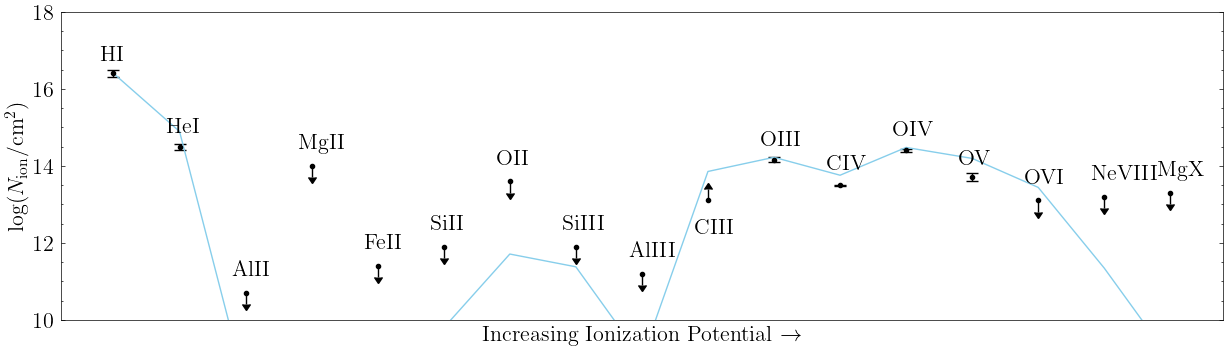

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

# Low density phase

In [94]:
logN_dict = {#'HI':'16.4, -0.1, +0.1',
            #'HeI':'14.49, -0.07, +0.07',
            'CIII':'>13.1',
            'CIV':'13.49, -0.02, +0.02',
            #'OII':'<13.6',
            'OIII':'<14.16',
            'OIV':'14.40, -0.04, +0.04',
            'OV':'<13.7',
            'OVI':'<13.1',}
            #'NeVIII':'<13.2',
            #'MgII':'<14.0',
            #'MgX':'<13.3',}
            #'AlII':'<10.7',
            #'AlIII':'<11.2',
            #'SiII':'<11.9',
            #'SiIII': '<11.9', #'12.63, -0.07, +0.07',
            #'FeII':'<11.4'}

In [95]:
gen_logN_ratio_str(logN_dict['OV'], logN_dict['OIV'])

'<-0.70, 0.15'

In [96]:
logN_ratio_dict = {'OIII/OIV': '<-0.2, 0.2',
                   'OV/OIV': '<-0.7, 0.2',
                   'OVI/OIV': '<-1.3, 0.2',
                   #'NeVIII/OIV': '<13.2, 0.2',
                   #'MgX/OIV': '<-1.1, 0.2',
                   'CIII/CIV': '>-0.4, 0.3'}

(-2.2, 2.5)

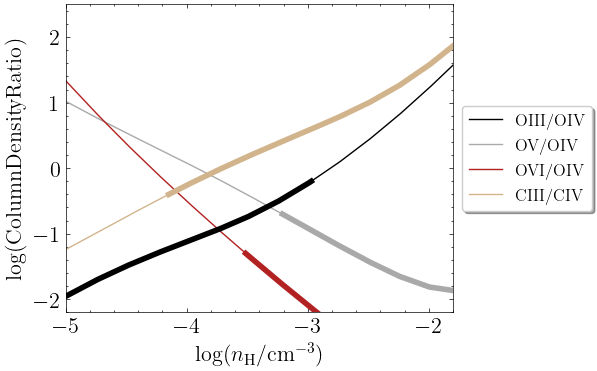

In [97]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2.5)

In [98]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [99]:
#pos = np.array(-3) + 1e-6 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [100]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [101]:
#sampler.run_mcmc(pos, 500, progress=True);

In [177]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_lo_c1.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c1.csv')

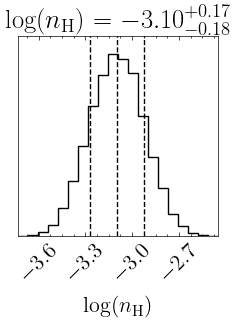

In [104]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [105]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [106]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

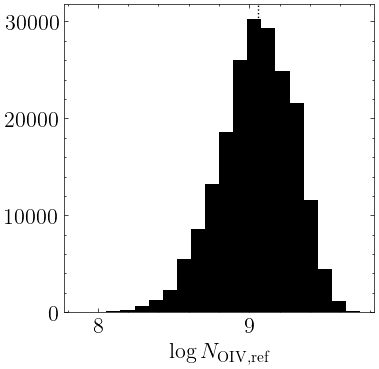

In [107]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

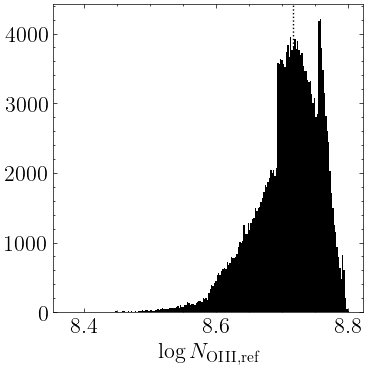

In [108]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

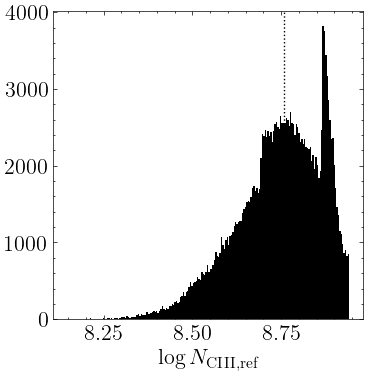

In [109]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [110]:
logN_offset = 14.40-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [111]:
logN_offset

5.341074616332781

Calculate the C/O ratio

In [112]:
logN_CIV_obs = np.random.normal(loc=13.49, scale=0.02, size=len(flat_samples_hdens))

In [113]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [122]:
get_quantiles(C_O_dist)

-0.11 -0.25 0.28


Get yields

In [123]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

14.06 -0.06 0.04


Plot models

In [128]:
logN_dict = {#'HI':'16.4, -0.1, +0.1',
            #'HeI':'14.49, -0.07, +0.07',
            'CIII':'>13.1',
            'CIV':'13.49, -0.02, +0.02',
            #'OII':'<13.6',
            'OIII':'14.16, -0.06, +0.06',
            'OIV':'14.40, -0.04, +0.04',
            'OV':'13.7, -0.1, +0.2',
            'OVI':'<13.1',}
            #'NeVIII':'<13.2',
            #'MgII':'<14.0',
            #'MgX':'<13.3',}
            #'AlII':'<10.7',
            #'AlIII':'<11.2',
            #'SiII':'<11.9',
            #'SiIII': '<11.9', #'12.63, -0.07, +0.07',
            #'FeII':'<11.4'}

In [129]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

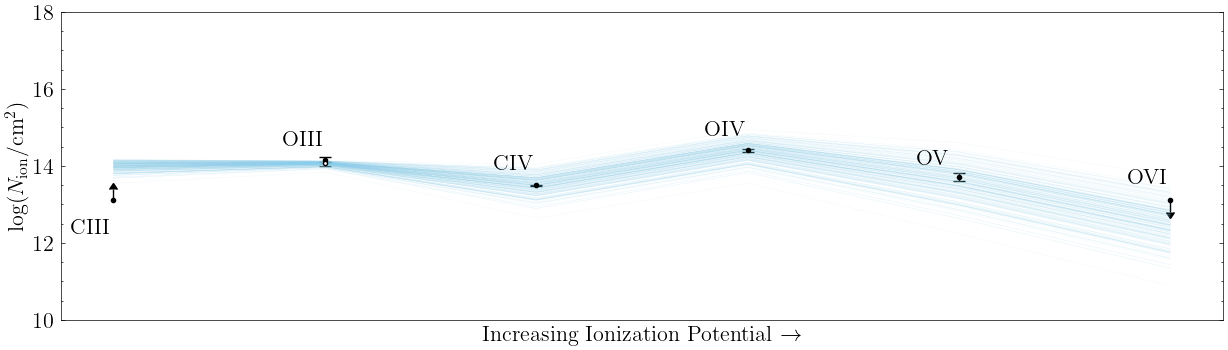

In [130]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.errorbar(x=1, y=14.06, yerr=[[0.06],[0.04]], color='black', linestyle='None', mfc='white',
        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for OIII

In [131]:
logN_OIII_tot = np.random.normal(loc=14.40, scale=0.04, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=14.06, scale=0.06, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

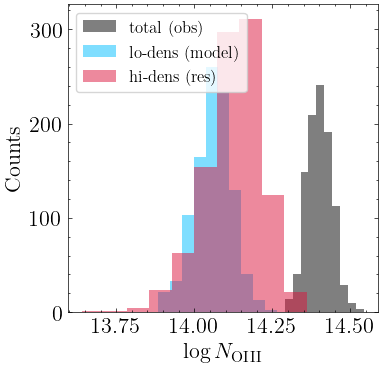

In [132]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [133]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [134]:
get_quantiles(logN_OIII_hi_dens_clean)

14.13 -0.1 0.08


# High density phase

In [144]:
logN_dict = {#'HI':'16.4, -0.1, +0.1',
            #'HeI':'14.49, -0.07, +0.07',
            #'CIII':'>13.1',
            #'CIV':'13.49, -0.02, +0.02',
            'OII':'<13.6',
            'OIII':'14.1, -0.1, +0.1',
            'OIV':'<14.40',
            #'OV':'13.7, -0.1, +0.2',
            #'OVI':'<13.1',
            #'NeVIII':'<13.2',
            'MgII':'<14.0',}
            #'MgX':'<13.3',
            #'AlII':'<10.7',
            #'AlIII':'<11.2',
            #'SiII':'<11.9',
            #'SiIII': '<11.9', #'12.63, -0.07, +0.07',
            #'FeII':'<11.4'}

In [147]:
gen_logN_ratio_str(logN_dict['OII'], logN_dict['OIII'])

'<-0.50, 0.17'

In [148]:
logN_ratio_dict = {
                   'OII/OIII': '<-0.5, 0.2',
                   'MgII/OIII': '<-0.1, 0.2',
                   'OIV/OIII': '<0.3, 0.2',
                  }

(-5.0, 5.0)

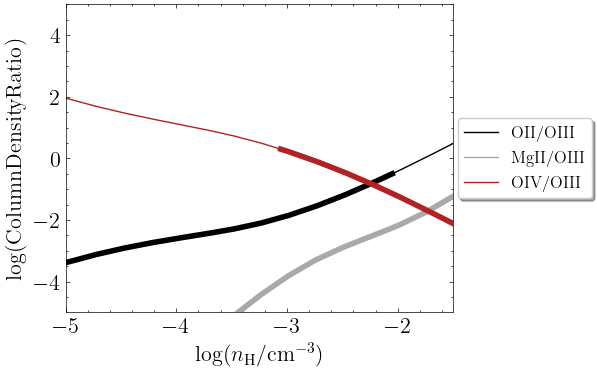

In [149]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [150]:
#pos = np.array(-2.6) + 1e-6 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [151]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [152]:
#sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [05:01<00:00,  1.66it/s]


In [178]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_hi_c1.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_hi_c1.csv')

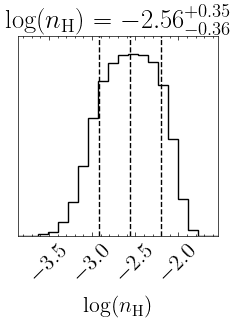

In [154]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [155]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [156]:
logN_offset = 14.1-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [157]:
logN_offset

5.637117233927301

Plot models

In [158]:
logN_dict = {#'HI':'16.4, -0.1, +0.1',
            #'HeI':'14.49, -0.07, +0.07',
            #'CIII':'>13.1',
            #'CIV':'13.49, -0.02, +0.02',
            'OII':'<13.6',
            'OIII':'14.1, -0.1, +0.1',
            'OIV':'<14.40',
            #'OV':'13.7, -0.1, +0.2',
            #'OVI':'<13.1',
            #'NeVIII':'<13.2',
            'MgII':'<14.0',}
            #'MgX':'<13.3',
            #'AlII':'<10.7',
            #'AlIII':'<11.2',
            #'SiII':'<11.9',
            #'SiIII': '<11.9', #'12.63, -0.07, +0.07',
            #'FeII':'<11.4'}

In [159]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

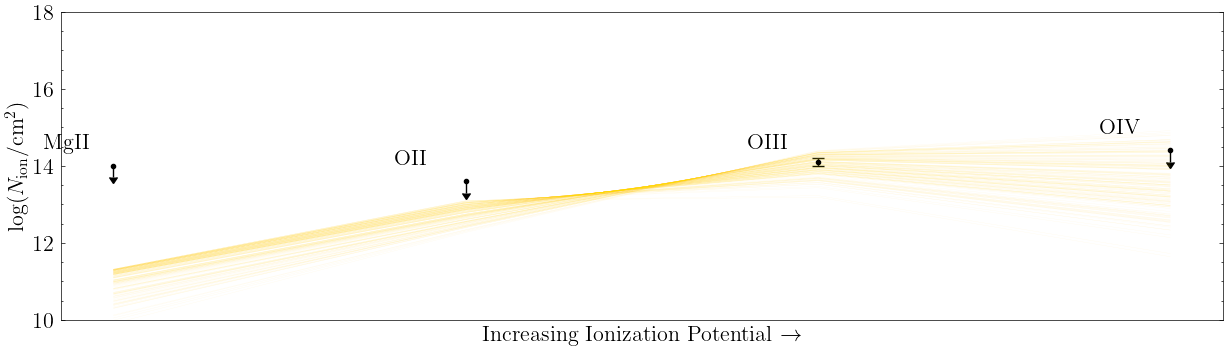

In [160]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [161]:
get_cloud_size(16.4, -2.6, species_logN_interp)

3.656731816338149

From the plot above, HeI/HI does not produce a consistent gas density with that predicted from oxygen ions. In fact, even between OIV/OIII and OV/OIV, there is some tension, which may certainly imply at least two gas phases (since scenario one doesn't apply here). But for HeI, it may be underproduced because of local ionizing fluctuations (CUBS-VI), so it's best not to include it in ionization modeling initially.

# Fit gas density

In [24]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [25]:
logN_ratio_dict

{'OII/OIII': '<-0.6, 0.2',
 'OIV/OIII': '0.24, -0.07, 0.07',
 'CIII/CIV': '>-0.4, 0.3'}

In [26]:
pos = np.array(-3) + 1e-4 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [27]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [28]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [05:38<00:00,  1.48it/s]


In [29]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

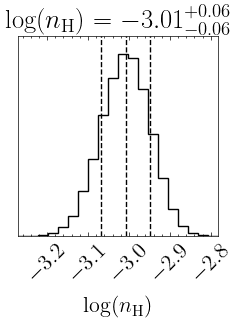

In [30]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [31]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [32]:
logN_offset = 14.16-np.mean(species_logN_interp['O+2'](grid_points_hdens))

Calculate C/O ratio

In [87]:
logN_CIV_obs = np.random.normal(loc=13.49, scale=0.02, size=len(flat_samples_hdens))

In [88]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [89]:
get_quantiles(C_O_dist)

-0.11 -0.25 0.28


Get yields

In [90]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

14.06 -0.06 0.04


Plot models

In [48]:
logN_dict = {#'HI':'16.4, -0.1, +0.1',
            #'HeI':'14.49, -0.07, +0.07',
            'CIII':'>13.1',
            'CIV':'13.49, -0.02, +0.02',
            #'OII':'<13.6',
            'OIII':'<14.16',
            'OIV':'14.40, -0.04, +0.04',
            'OV':'<13.7',
            'OVI':'<13.1',}
            #'NeVIII':'<13.2',
            #'MgII':'<14.0',
            #'MgX':'<13.3',}
            #'AlII':'<10.7',
            #'AlIII':'<11.2',
            #'SiII':'<11.9',
            #'SiIII': '<11.9', #'12.63, -0.07, +0.07',
            #'FeII':'<11.4'}

In [49]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

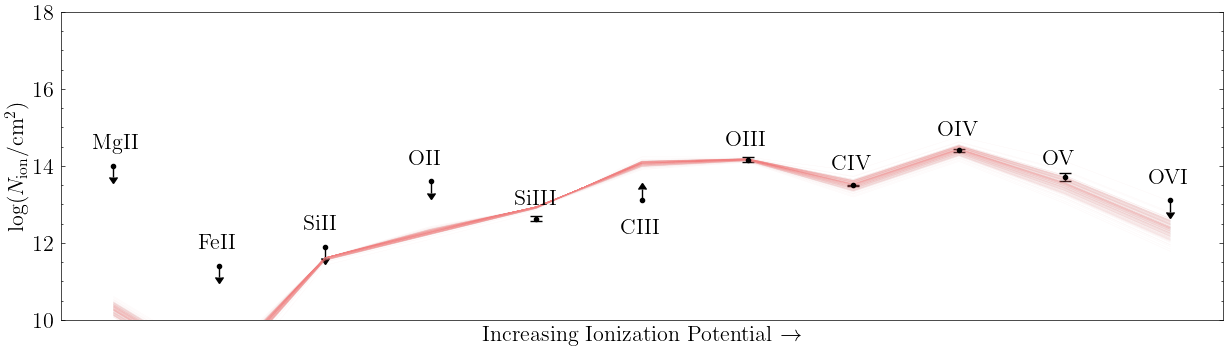

In [50]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.1)

Compare OIII column densities

In [97]:
logN_OIII_samples = species_logN_interp['O+2'](grid_points_hdens)+logN_offset

In [98]:
np.median(logN_OIII_samples), np.median(logN_OIII_samples)-np.percentile(logN_OIII_samples, 100*(1-cdf_1sig))

(13.951759979942569, 0.04856432975462788)

In [99]:
logN_OIII_tot = np.random.normal(loc=14.16, scale=0.06, size=1000)
logN_OIII_hi_dens = np.random.normal(loc=13.95, scale=0.05, size=1000)
logN_OIII_lo_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_hi_dens)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_46571/726557410.py:3: RuntimeWarning: invalid value encountered in log10
  logN_OIII_lo_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_hi_dens)


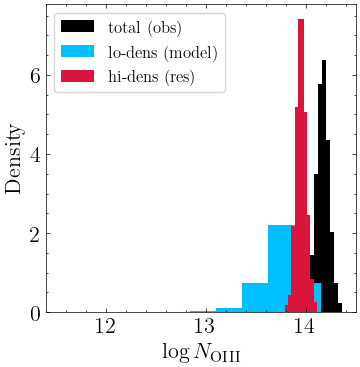

In [100]:
fig, ax = plt.subplots(1, figsize=(4,4))

plt.hist(logN_OIII_tot, density=True, label='total (obs)')
plt.hist(logN_OIII_lo_dens, density=True, label='lo-dens (model)')
plt.hist(logN_OIII_hi_dens, density=True, label='hi-dens (res)')

#plt.hist(logN_OIII_dist_res, density=True)
#plt.hist(logN_OIII_samples, density=True)
ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Density')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [101]:
np.median(logN_OIII_hi_dens), np.median(logN_OIII_hi_dens)-np.percentile(logN_OIII_hi_dens, 100*(1-cdf_1sig))

(13.948069375391304, 0.049611727034330144)

Compare SiIII column densities

In [102]:
logN_SiIII_samples = species_logN_interp['Si+2'](grid_points_hdens)+logN_offset

In [103]:
np.median(logN_SiIII_samples), np.median(logN_SiIII_samples)-np.percentile(logN_SiIII_samples, 100*(1-cdf_1sig))

(12.570943125299944, 0.20530214104359246)

In [104]:
logN_SiIII_tot = np.random.normal(loc=12.63, scale=0.07, size=1000)
logN_SiIII_hi_dens = np.random.normal(loc=12.6, scale=0.2, size=1000)
logN_SiIII_lo_dens = np.log10(10**logN_SiIII_tot - 10**logN_SiIII_hi_dens)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_46571/881567822.py:3: RuntimeWarning: invalid value encountered in log10
  logN_SiIII_lo_dens = np.log10(10**logN_SiIII_tot - 10**logN_SiIII_hi_dens)


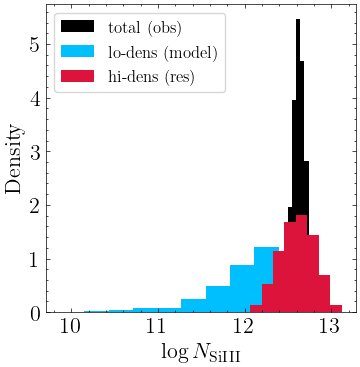

In [105]:
fig, ax = plt.subplots(1, figsize=(4,4))

plt.hist(logN_SiIII_tot, density=True, label='total (obs)')
plt.hist(logN_SiIII_lo_dens, density=True, label='lo-dens (model)')
plt.hist(logN_SiIII_hi_dens, density=True, label='hi-dens (res)')

#plt.hist(logN_OIII_dist_res, density=True)
#plt.hist(logN_OIII_samples, density=True)
ax.set_xlabel(r'$\log N_{\mathrm{SiIII}}$')
ax.set_ylabel('Density')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [106]:
(np.median(logN_SiIII_hi_dens), 
np.median(logN_SiIII_hi_dens)-np.percentile(logN_SiIII_hi_dens, 100*(1-cdf_1sig)),
np.median(logN_SiIII_hi_dens)-np.percentile(logN_SiIII_hi_dens, 100*cdf_1sig))

(12.609353918933285, 0.1947001959964183, -0.2033299494175882)

# High density phase

In [107]:
logN_dict = {'HI':'16.4, -0.1, +0.1',
            'HeI':'14.49, -0.07, +0.07',
            'CIII':'>13.1',
            'CIV':'13.49, -0.02, +0.02',
            'OII':'<13.6',
            'OIII':'14.16, -0.06, +0.06',
            'OIV':'13.95, -0.04, +0.04',
            'OV':'13.7, -0.1, +0.2',
            'OVI':'<13.1',
            'NeVIII':'<13.2',
            'MgII':'<14.0',
            'MgX':'<13.3',
            'AlII':'<10.7',
            'AlIII':'<11.2',
            'SiII':'<11.9',
            'SiIII': '12.6, -0.2, +0.2',
            'FeII':'<11.4'}

Generate column density ratios

In [69]:
gen_logN_ratio_str(logN_dict['MgII'], logN_dict['OIII'])

'<-0.16, 0.15'

In [110]:
logN_ratio_dict = {'OII/OIII': '<-0.56, 0.15',
                   #'SiIII/OIII': '-1.6, -0.2, 0.2',
                   #'SiII/OIII': '<-2.3, 0.2',
                   'MgII/OIII': '<-0.2, 0.2'}

(-5.0, 0.0)

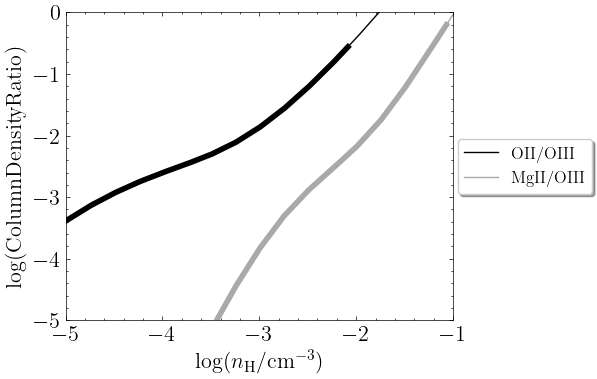

In [111]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1)
ax.set_ylim(-5, 0)

In [112]:
pos = np.array(-2.5) + 1e-4 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [113]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [114]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [03:49<00:00,  2.18it/s]


In [115]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])
#flat_samples_oxy_sul.to_csv(savedir+'oxy_sul_solar_flat.csv', index=False)

#flat_samples_oxy_sul = pd.read_csv(savedir+'oxy_sul_solar_flat.csv')

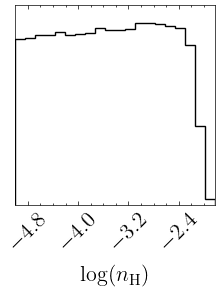

In [116]:
fig = corner.corner(
    flat_samples_hdens, #quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [121]:
np.percentile(flat_samples_hdens['log_hdens'], 100*cdf_3sig)

-1.9659193892495856

In [117]:
pdf, edges = np.histogram(flat_samples_hdens['log_hdens'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

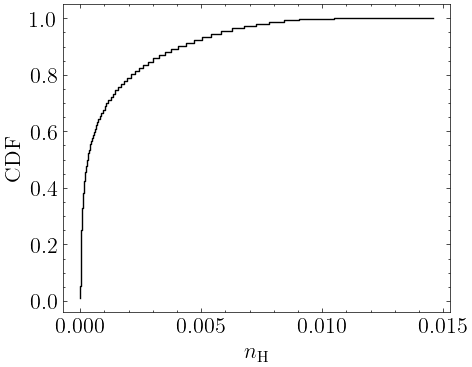

In [119]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$n_\mathrm{H}$')
ax.set_ylabel('CDF')

In [122]:
10**np.log10(ppf(cdf_3sig))

0.010543569837868081

# Single phase, oxygen only fit

In [151]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if -3.5<log_hdens<log_hdens_max and log_metals_min<log_metals<log_metals_max:
        return 0.0
    return -np.inf

In [152]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [153]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [154]:
ions_oxy = ['OII', 'OIII', 'OIV', 'CIII', 'CIV']

In [155]:
logN_dict_oxy = {ion: logN_dict[ion] for ion in ions_oxy}

In [156]:
logN_dict_oxy

{'OII': '<13.6',
 'OIII': '14.16, -0.06, +0.06',
 'OIV': '14.40, -0.04, +0.04',
 'CIII': '>13.1',
 'CIV': '13.49, -0.02, +0.02'}

In [157]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [158]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy, species_logN_interp)
)

In [76]:
sampler.run_mcmc(pos, 500, progress=True);

  0%|                                                                       | 0/500 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████████████████████████████| 500/500 [04:40<00:00,  1.79it/s]


In [159]:
#flat_samples_oxy = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens', 'log_metals'])
#flat_samples_oxy.to_csv(savedir+'oxy_solar_flat_c1.csv', index=False)

flat_samples_oxy = pd.read_csv(savedir+'oxy_solar_flat_c1.csv')

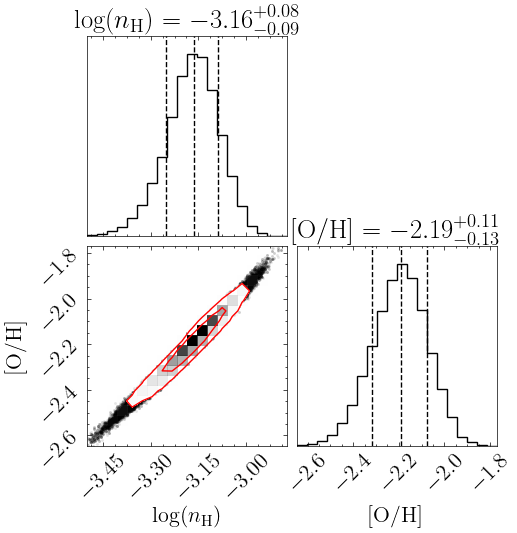

In [160]:
fig = corner.corner(
    flat_samples_oxy.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [161]:
logN_dict = {'HI':'16.35, -0.13, +0.13',
            'HeI':'14.49, -0.07, +0.07',
            'CIII':'>13.1',
            'CIV':'13.49, -0.02, +0.02',
            'OII':'<13.6',
            'OIII':'14.16, -0.06, +0.06',
            'OIV':'14.40, -0.04, +0.04',
            'OV':'13.73, -0.14, +0.23',
            'OVI':'<13.1',
            'NeVIII':'<13.2',
            'MgII':'<14.0',
            'MgX':'<13.3',
            'AlII':'<10.7',
            'AlIII':'<11.2',
            'SiII':'<11.9',
            'SiIII': '<11.9',#'12.63, -0.07, +0.07',
            'FeII':'<11.4'}

In [162]:
sample_indices_oxy = np.random.randint(low=0, high=len(flat_samples_oxy), size=200)

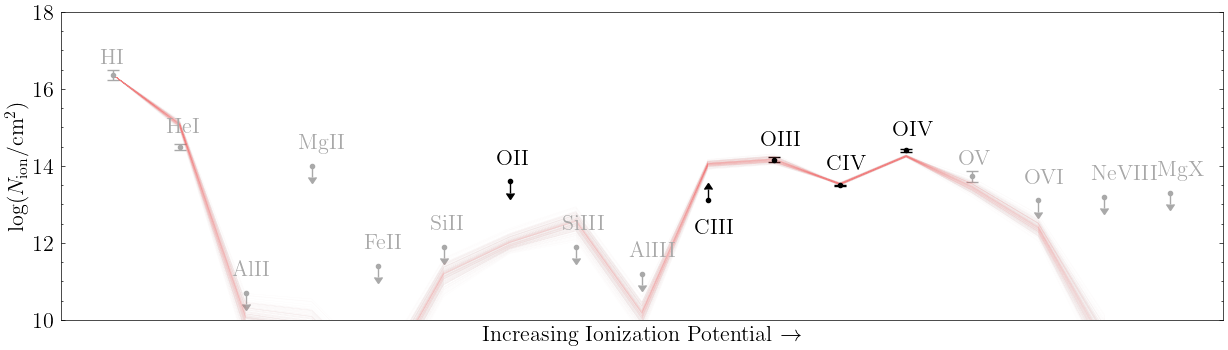

In [163]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'HeI', 'OV', 'OVI', 
                                                         'NeVIII', 'MgII', 'MgX', 
                                                         'AlII', 'AlIII', 'SiII', 'SiIII', 'FeII'])

for i in range(len(sample_indices_oxy)):
    
    idx = sample_indices_oxy[i]
    flat_samples_row = flat_samples_oxy.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

#ax.text(x=0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.6 \pm 0.2$')
#ax.text(x=0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = -2.6 \pm 0.2$')

#plt.savefig(savedir+'z=1_1659134_cloudy_oxy_c1.pdf', dpi=300)

Plot the posterior for cloud size

In [82]:
flat_samples_oxy['logN_HII'] = [species_logN_interp['H+']([logN_HI_test,
                                                            flat_samples_oxy.iloc[i]['log_hdens'],
                                                            flat_samples_oxy.iloc[i]['log_metals']])[0]
                                               for i in range(len(flat_samples_oxy))]

In [83]:
flat_samples_oxy['cloud_size_kpc'] = ((10**logN_HI_test+10**flat_samples_oxy['logN_HII'])/10**flat_samples_oxy['log_hdens'])*3.24078e-19*1e-3

In [84]:
l_med = np.median(flat_samples_oxy['cloud_size_kpc'])
l_perc_16 = np.percentile(flat_samples_oxy['cloud_size_kpc'],16)
l_perc_84 = np.percentile(flat_samples_oxy['cloud_size_kpc'],84)

In [85]:
l_med, l_med-l_perc_16, l_perc_84-l_med

(55.188918306721355, 18.11877646493945, 30.821860237100275)

In [86]:
#np.percentile(flat_samples_oxy['cloud_size_kpc'],100*cdf_3sig)

Text(0, 0.5, 'Probability Density')

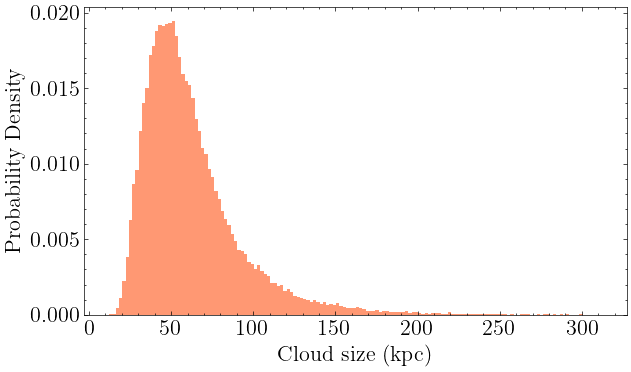

In [87]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_oxy['cloud_size_kpc'], bins=150, density=True, color='coral', alpha=.8)
#ax.axvline(l_med, linestyle=':', lw=2)
#ax.axvline(l_perc_16, linestyle=':', lw=2)
#ax.axvline(l_perc_84, linestyle=':', lw=2)

#ax.text(140, 0.03, s=r'$\log N_{\mathrm{HI}} = 16.64 \pm 0.01$')
#ax.text(140, 0.022, s=r'$l < 200 \ \mathrm{kpc}$')

ax.set_xlabel('Cloud size (kpc)')
ax.set_ylabel('Probability Density')

# Component 2

Enter measurements for species

In [162]:
logN_dict = {'HI':'14.6, -0.2, +0.2',
            'HeI':'<12.6',
            'CIII':'<12.8',
            'CIV':'13.01, -0.06, +0.06',
            'OII':'<13.7',
            'OIII':'<13.1',
            'OIV':'13.6, -0.2, +0.2',
            'OV':'13.82, -0.06, +0.06',
            'OVI':'13.8, -0.1, +0.1',
            'NeVIII':'<13.3',
            'MgII':'<14.0',
            'MgX':'<13.4',
            'AlII':'<10.9',
            'AlIII':'<11.4',
            'SiII':'<12.0',
            'SiIII':'<11.9',
            'FeII':'<11.6'}

Try out a solution

In [163]:
logN_HI_test = 14.6
log_hdens_test = -4.2
log_metals_test = -1.8

In [164]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

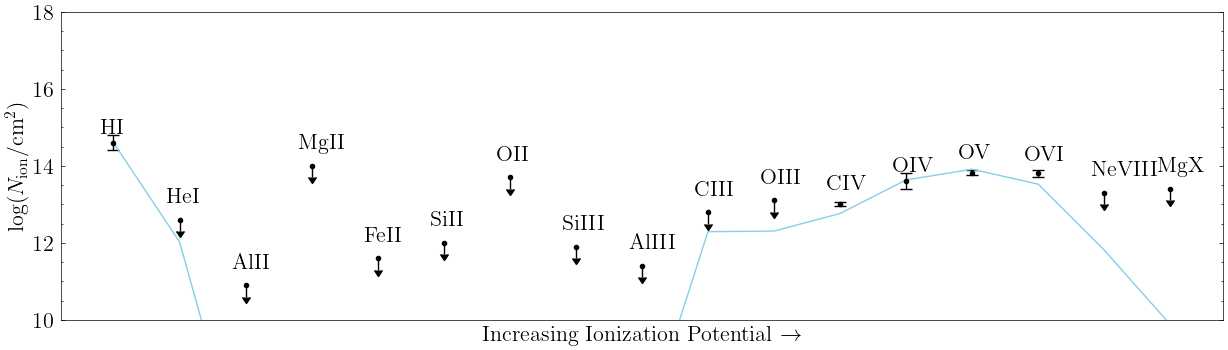

In [165]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

# Low density phase

In [166]:
logN_dict = {#'HI':'14.6, -0.2, +0.2',
            #'HeI':'<12.6',
            'CIII':'<12.8',
            'CIV':'13.01, -0.06, +0.06',
            #'OII':'<13.7',
            'OIII':'<13.1',
            'OIV':'13.6, -0.2, +0.2',
            'OV':'<13.82',
            'OVI':'<13.8',
            'NeVIII':'<13.3',
            #'MgII':'<14.0',
            'MgX':'<13.4',}
            #'AlII':'<10.9',
            #'AlIII':'<11.4',
            #'SiII':'<12.0',
            #'SiIII':'<11.9',
            #'FeII':'<11.6'}

Get column density ratios

In [172]:
gen_logN_ratio_str(logN_dict['CIII'], logN_dict['CIV'])

'<-0.21, 0.15'

In [175]:
logN_ratio_dict = {'OIII/OIV': '<-0.5, 0.2',
                   'OV/OIV': '<0.2, 0.2',
                   'OVI/OIV': '<0.2, 0.2',
                   #'NeVIII/OIV': '<-0.3, 0.2',
                   #'MgX/OIV': '<-0.2, 0.2',
                   'CIII/CIV': '<-0.2, 0.2'}

Generate predicted column density ratios

(-2.2, 2.0)

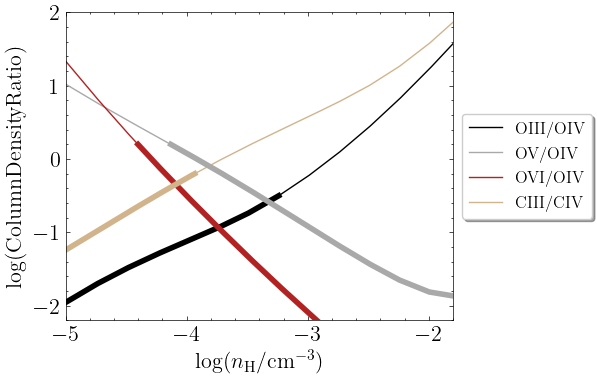

In [176]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2)

In [179]:
pos = np.array(-4) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [180]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [181]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [06:37<00:00,  1.26it/s]


In [182]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_lo_c2.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c2.csv')

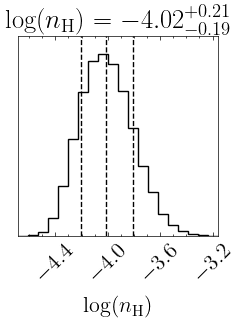

In [183]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [184]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [185]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

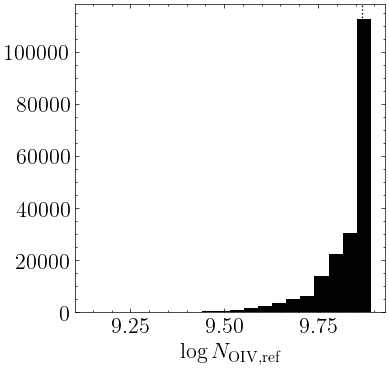

In [186]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [187]:
logN_offset = 13.6-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [188]:
logN_offset

3.7336630078954176

Calculate the C/O ratio

In [189]:
logN_CIV_obs = np.random.normal(loc=13.01, scale=0.06, size=len(flat_samples_hdens))

In [190]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [191]:
get_quantiles(C_O_dist)

0.32 -0.07 0.07


Plot models

In [192]:
logN_dict = {#'HI':'14.6, -0.2, +0.2',
            #'HeI':'<12.6',
            'CIII':'<12.8',
            'CIV':'13.01, -0.06, +0.06',
            #'OII':'<13.7',
            'OIII':'<13.1',
            'OIV':'13.6, -0.2, +0.2',
            'OV':'13.82, -0.06, +0.06',
            'OVI':'13.8, -0.1, +0.1',
            'NeVIII':'<13.3',
            #'MgII':'<14.0',
            'MgX':'<13.4',}
            #'AlII':'<10.9',
            #'AlIII':'<11.4',
            #'SiII':'<12.0',
            #'SiIII':'<11.9',
            #'FeII':'<11.6'}

In [193]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

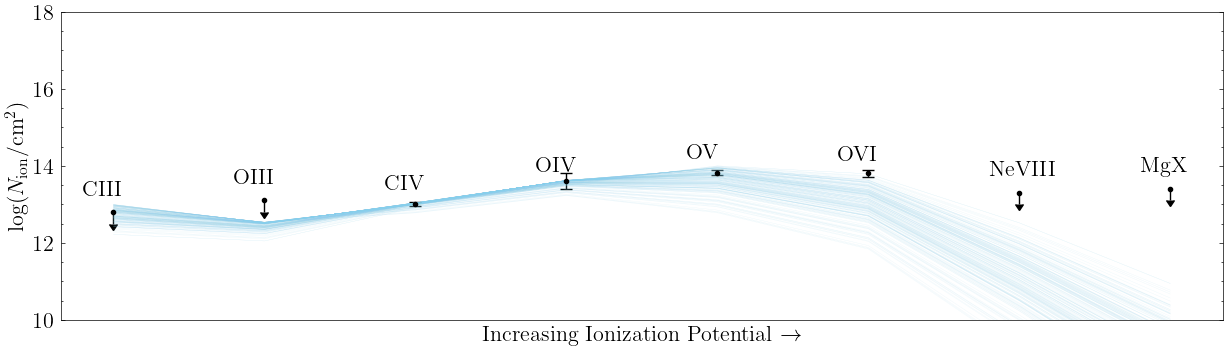

In [196]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

# Fit gas density

In [70]:
logN_ratio_dict

{'OII/OIV': '<0.1, 0.2',
 'OIII/OIV': '<-0.5, 0.2',
 'OV/OIV': '0.2, -0.2, 0.2',
 'CIII/CIV': '<-0.2, 0.2'}

In [71]:
pos = np.array(-4.2) + 1e-4 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [72]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [73]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [06:44<00:00,  1.24it/s]


In [74]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

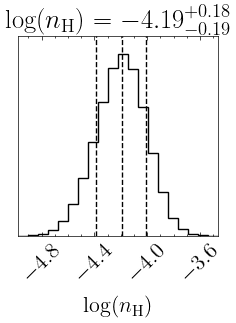

In [84]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [85]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [86]:
logN_offset = 13.6-np.mean(species_logN_interp['O+3'](grid_points_hdens))

Calculate C/O ratio

In [87]:
logN_CIV_obs = np.random.normal(loc=13.01, scale=0.06, size=len(flat_samples_hdens))

In [88]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [89]:
(np.round(np.median(C_O_dist), 2), 
np.round(np.percentile(C_O_dist, 100*(1-cdf_1sig))-np.median(C_O_dist), 2),
np.round(np.percentile(C_O_dist, 100*cdf_1sig)-np.median(C_O_dist), 2))

(0.31, -0.07, 0.08)

Plot models

In [90]:
logN_dict = {#'HI':'14.6, -0.2, +0.2',
            #'HeI':'<12.6',
            'CIII':'<12.8',
            'CIV':'13.01, -0.06, +0.06',
            'OII':'<13.7',
            'OIII':'<13.1',
            'OIV':'13.6, -0.2, +0.2',
            'OV':'13.82, -0.06, +0.06',
            'OVI':'13.8, -0.1, +0.1',
            'NeVIII':'<13.3',
            'MgII':'<14.0',
            'MgX':'<13.4',
            #'AlII':'<10.9',
            #'AlIII':'<11.4',
            'SiII':'<12.0',
            'SiIII':'<11.9',
            'FeII':'<11.6'}

In [91]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

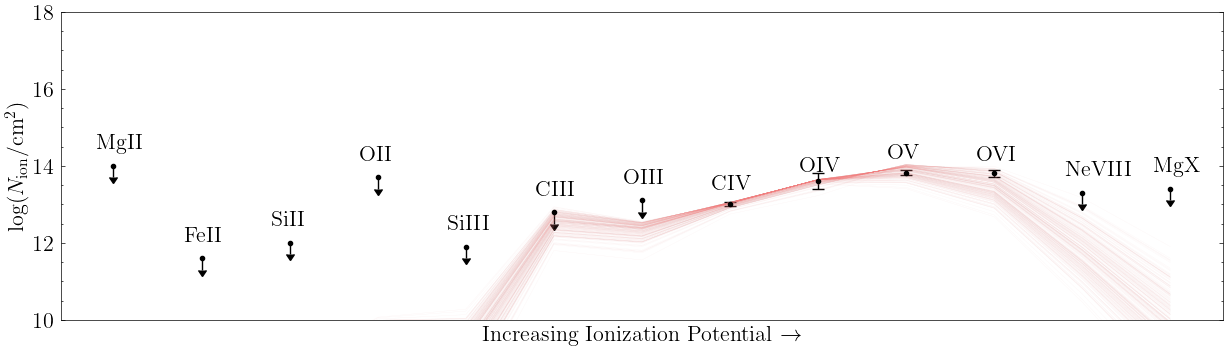

In [95]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C':np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.1)

Compare CIV column densities

In [145]:
logN_CIV_samples = species_logN_interp['C+3'](grid_points_hdens)+logN_offset

In [146]:
np.median(logN_CIV_samples), np.median(logN_CIV_samples)-np.percentile(logN_CIV_samples, 100*(1-cdf_1sig))

(12.718589084819547, 0.06417232480171187)

In [147]:
logN_CIV_tot = np.random.normal(loc=13.01, scale=0.06, size=1000)
logN_CIV_hi_dens = np.random.normal(loc=12.72, scale=0.06, size=1000)
logN_CIV_lo_dens = np.log10(10**logN_CIV_tot - 10**logN_CIV_hi_dens)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_46571/3219609510.py:3: RuntimeWarning: invalid value encountered in log10
  logN_CIV_lo_dens = np.log10(10**logN_CIV_tot - 10**logN_CIV_hi_dens)


In [149]:
C_O_dist = logN_CIV_tot - logN_CIV_hi_dens

In [153]:
np.round(np.median(C_O_dist), 2), np.round(np.median(C_O_dist)-np.percentile(C_O_dist, 100*(1-cdf_1sig)), 2)

(0.29, 0.08)

Text(0.5, 0, '[C/O]')

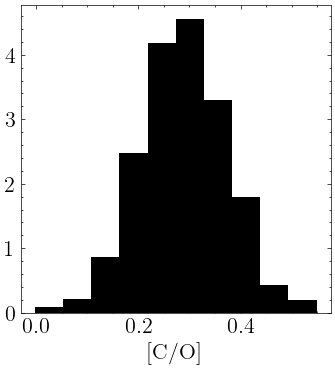

In [150]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(C_O_dist, density=True)

ax.set_xlabel('[C/O]')

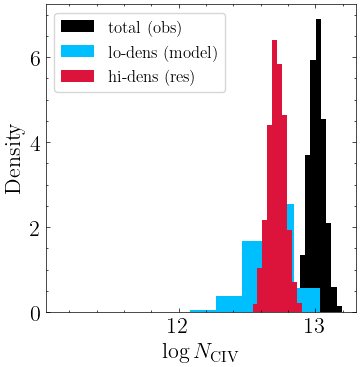

In [148]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_CIV_tot, density=True, label='total (obs)')
ax.hist(logN_CIV_lo_dens, density=True, label='lo-dens (model)')
ax.hist(logN_CIV_hi_dens, density=True, label='hi-dens (res)')

#plt.hist(logN_OIII_dist_res, density=True)
#plt.hist(logN_OIII_samples, density=True)
ax.set_xlabel(r'$\log N_{\mathrm{CIV}}$')
ax.set_ylabel('Density')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [101]:
np.median(logN_OIII_hi_dens), np.median(logN_OIII_hi_dens)-np.percentile(logN_OIII_hi_dens, 100*(1-cdf_1sig))

(13.948069375391304, 0.049611727034330144)

In [ ]:
Compare OIII column densities

logN_OIII_samples = species_logN_interp['O+2'](grid_points_hdens)+logN_offset

np.median(logN_OIII_samples), np.median(logN_OIII_samples)-np.percentile(logN_OIII_samples, 100*(1-cdf_1sig))

logN_OIII_tot = np.random.normal(loc=14.16, scale=0.06, size=1000)
logN_OIII_hi_dens = np.random.normal(loc=13.95, scale=0.05, size=1000)
logN_OIII_lo_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_hi_dens)

fig, ax = plt.subplots(1, figsize=(4,4))

plt.hist(logN_OIII_tot, density=True, label='total (obs)')
plt.hist(logN_OIII_lo_dens, density=True, label='lo-dens (model)')
plt.hist(logN_OIII_hi_dens, density=True, label='hi-dens (res)')

#plt.hist(logN_OIII_dist_res, density=True)
#plt.hist(logN_OIII_samples, density=True)
ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Density')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

np.median(logN_OIII_hi_dens), np.median(logN_OIII_hi_dens)-np.percentile(logN_OIII_hi_dens, 100*(1-cdf_1sig))

# Single phase, oxygen only fit

In [95]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if log_hdens_min<log_hdens<log_hdens_max and log_metals_min<log_metals<log_metals_max:
        return 0.0
    return -np.inf

In [96]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [97]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [118]:
ions_oxy = ['OII','OIII', 'OIV', 'OV', 'CIII', 'CIV']

In [119]:
logN_dict_oxy = {ion: logN_dict[ion] for ion in ions_oxy}

In [120]:
logN_dict_oxy

{'OII': '<13.7',
 'OIII': '<13.1',
 'OIV': '13.60, -0.23, +0.16',
 'OV': '13.82, -0.06, +0.06',
 'CIII': '<12.8',
 'CIV': '13.01, -0.06, +0.06'}

In [121]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [122]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy, species_logN_interp)
)

In [123]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████████████████████████| 500/500 [05:48<00:00,  1.43it/s]


In [124]:
flat_samples_oxy = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens', 'log_metals'])
flat_samples_oxy.to_csv(savedir+'oxy_solar_flat_c2.csv', index=False)

#flat_samples_oxy = pd.read_csv(savedir+'oxy_solar_flat_c2.csv')

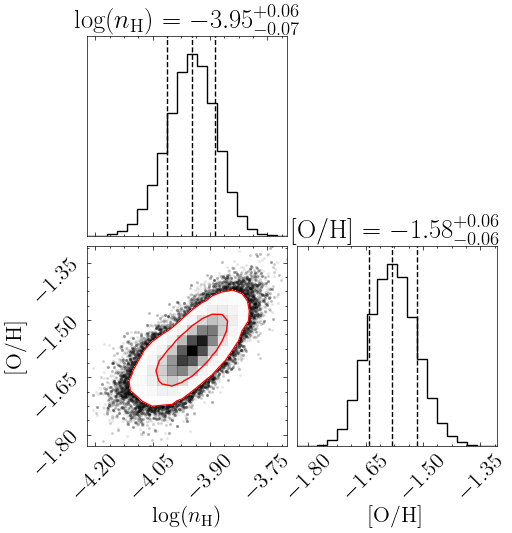

In [125]:
fig = corner.corner(
    flat_samples_oxy.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [126]:
logN_dict = {'HI':'14.59, -0.17, +0.17',
            'HeI':'<12.6',
            'CIII':'<12.8',
            'CIV':'13.01, -0.06, +0.06',
            'OII':'<13.7',
            'OIII':'<13.1',
            'OIV':'13.60, -0.23, +0.16',
            'OV':'13.82, -0.06, +0.06',
            'OVI':'13.85, -0.13, +0.11',
            'NeVIII':'<13.3',
            'MgII':'<14.0',
            'MgX':'<13.4',
            'AlII':'<10.9',
            'AlIII':'<11.4',
            'SiII':'<12.0',
            'SiIII':'<11.9',
            'FeII':'<11.6'}

In [127]:
sample_indices_oxy = np.random.randint(low=0, high=len(flat_samples_oxy), size=200)

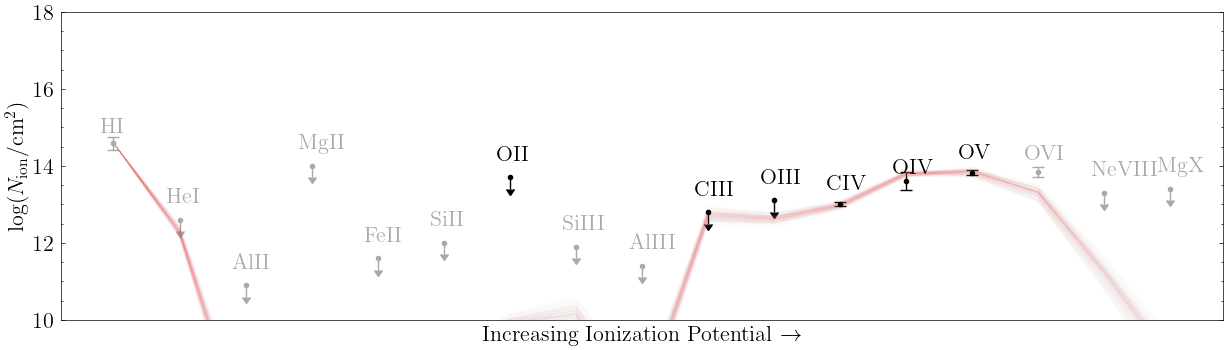

In [128]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'HeI', 'OVI',
                                                         'NeVIII', 'MgII', 'MgX', 
                                                         'AlII', 'AlIII', 'SiII', 'SiIII', 'FeII'])

for i in range(len(sample_indices_oxy)):
    
    idx = sample_indices_oxy[i]
    flat_samples_row = flat_samples_oxy.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

#ax.text(x=-0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -4.22 \pm 0.08$')
#ax.text(x=-0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = -1.54 \pm 0.09$')

#plt.savefig(savedir+'z=1_1659134_cloudy_oxy_c2.pdf', dpi=300)

Plot the posterior for cloud size

In [129]:
flat_samples_oxy['logN_HII'] = [species_logN_interp['H+']([logN_HI_test,
                                                            flat_samples_oxy.iloc[i]['log_hdens'],
                                                            flat_samples_oxy.iloc[i]['log_metals']])[0]
                                               for i in range(len(flat_samples_oxy))]

In [130]:
flat_samples_oxy['cloud_size_kpc'] = ((10**logN_HI_test+10**flat_samples_oxy['logN_HII'])/10**flat_samples_oxy['log_hdens'])*3.24078e-19*1e-3

In [131]:
l_med = np.median(flat_samples_oxy['cloud_size_kpc'])
l_perc_16 = np.percentile(flat_samples_oxy['cloud_size_kpc'],16)
l_perc_84 = np.percentile(flat_samples_oxy['cloud_size_kpc'],84)

In [132]:
l_med, l_med-l_perc_16, l_perc_84-l_med

(37.95752438747863, 10.241899595717335, 14.945215148985795)

In [133]:
#np.percentile(flat_samples_oxy['cloud_size_kpc'],100*cdf_3sig)

Text(0, 0.5, 'Probability Density')

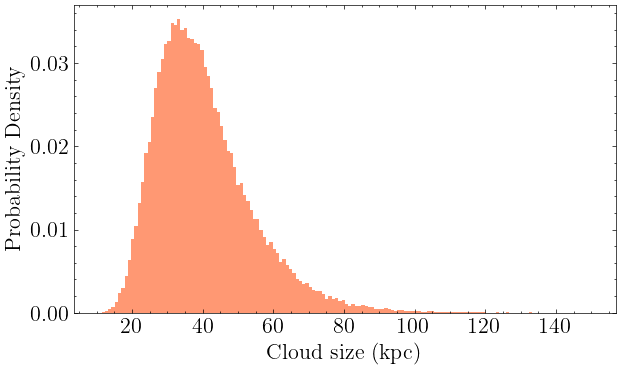

In [134]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_oxy['cloud_size_kpc'], bins=150, density=True, color='coral', alpha=.8)
#ax.axvline(l_med, linestyle=':', lw=2)
#ax.axvline(l_perc_16, linestyle=':', lw=2)
#ax.axvline(l_perc_84, linestyle=':', lw=2)

#ax.text(140, 0.03, s=r'$\log N_{\mathrm{HI}} = 16.64 \pm 0.01$')
#ax.text(140, 0.022, s=r'$l < 200 \ \mathrm{kpc}$')

ax.set_xlabel('Cloud size (kpc)')
ax.set_ylabel('Probability Density')

# Oxygen + Carbon fit

In [63]:
ions_oxy_carb = ['OII', 'OIII', 'OIV', 'OV', 'CIII', 'CIV']

In [64]:
logN_dict_oxy_carb = {ion: logN_dict[ion] for ion in ions_oxy_carb}

In [65]:
logN_dict_oxy_carb

{'OII': '<13.9',
 'OIII': '<13.5',
 'OIV': '13.85, -0.09, +0.09',
 'OV': '13.83, -0.05, +0.05',
 'CIII': '<13.1',
 'CIV': '13.03, -0.06, +0.06'}

In [66]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [67]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy, species_logN_interp)
)

In [68]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [04:04<00:00,  2.04it/s]


In [71]:
#flat_samples_oxy_carb = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens', 'log_metals'])
#flat_samples_oxy_carb.to_csv(savedir+'oxy_carb_solar_flat_c2.csv', index=False)

flat_samples_oxy_carb = pd.read_csv(savedir+'oxy_carb_solar_flat_c2.csv')

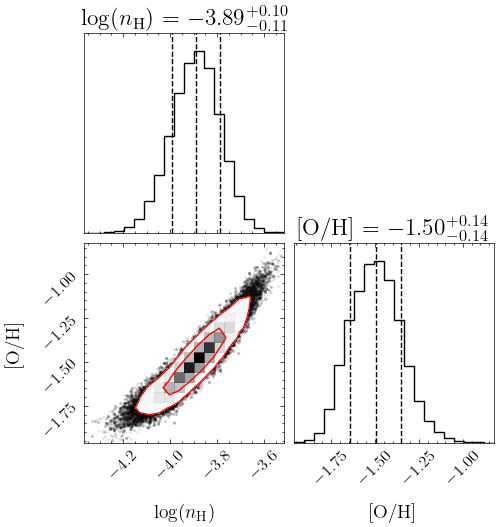

In [72]:
fig = corner.corner(
    flat_samples_oxy_carb, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [73]:
logN_dict = {'HI' : '14.6, -0.2, +0.2',
            'HeI' : '<13.0',
            'CIII' : '<13.1',
            'CIV' : '13.03, -0.06, +0.06',
            'OII' : '<13.9',
            'OIII' : '<13.5',
            'OIV' : '13.85, -0.09, +0.09',
            'OV' : '13.83, -0.05, +0.05',
            'OVI' : '13.8, -0.1, +0.1',
            'NeVIII' : '<13.6',
            'MgII' : '<15.6',
            'MgX' : '<13.7',
            'AlII' : '<11.2',
            'AlIII' : '<11.7',
            'SiII' : '<12.3',
            'FeII' : '<11.9'}

In [74]:
sample_indices_oxy_carb = np.random.randint(low=0, high=len(flat_samples_oxy_carb), size=200)

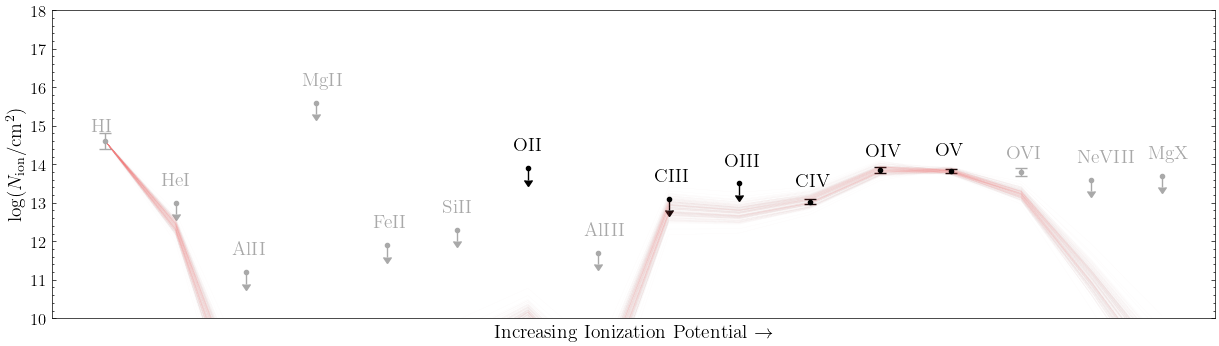

In [75]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'HeI', 'OVI',
                                                         'NeVIII', 'MgII', 'MgX', 
                                                         'AlII', 'AlIII', 'SiII', 'FeII'])

for i in range(len(sample_indices_oxy_carb)):
    
    idx = sample_indices_oxy_carb[i]
    flat_samples_row = flat_samples_oxy_carb.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

#ax.text(x=-0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -4.22 \pm 0.08$')
#ax.text(x=-0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = -1.54 \pm 0.09$')

#plt.savefig(savedir+'z=1_1659134_cloudy_oxy_c2.pdf', dpi=300)